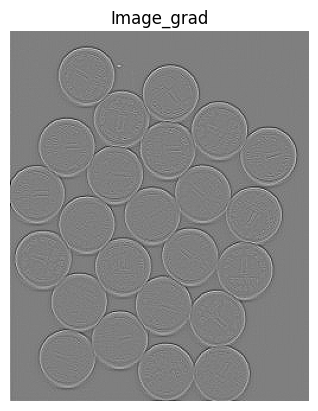

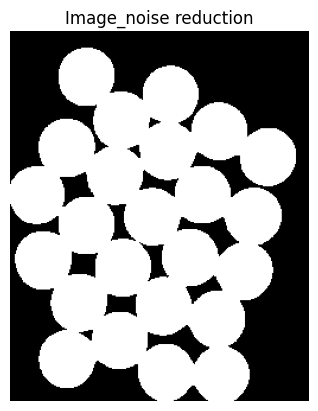

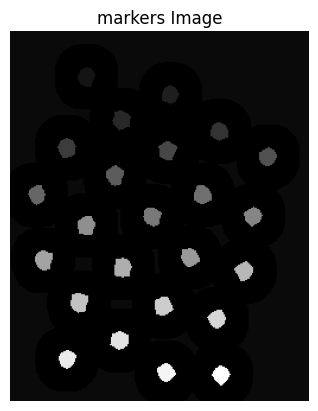

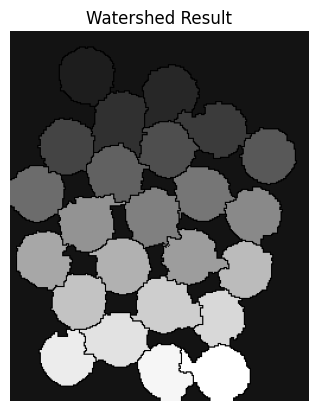

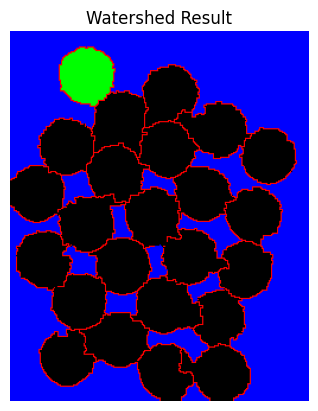

In [20]:
import numpy as np
import cv2
import heapq
import matplotlib.pyplot as plt

class SimpleWatershed:
    def __init__(self, image_path):
        self.original = cv2.imread(image_path)
        self.gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        self.grad = self._compute_gradient()
        #self.markers = np.zeros_like(self.gray, dtype=np.int32)
        self.label_img = None

    def show_Image(self, Image, title):
        plt.imshow(Image, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    def _compute_gradient(self):
        # 勾配画像（標高マップ）を作成
        grad = cv2.Laplacian(self.gray, cv2.CV_32F)
        # 勾配画像の表示
        self.show_Image(grad, "Image_grad")
        return cv2.convertScaleAbs(grad)
    
    def noise_reduction(self):
        ret, thresh = cv2.threshold(self.gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
        kernel = np.ones((3,3), np.uint8)
        morphologied = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
        self.kernel = kernel
        self.morphologied = morphologied
        # 結果の出力
        self.show_Image(morphologied, "Image_noise reduction")
    
    def finding_sure_background_area(self):
        sure_bg = cv2.dilate(self.morphologied, self.kernel, iterations = 3)
        self.sure_bg = sure_bg
        
    def finding_sure_foreground_area(self):
        dist_transform = cv2.distanceTransform(self.morphologied, cv2.DIST_L2, 5)
        ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
        self.sure_fg = sure_fg

    def finding_sure_unknown_area(self):
        sure_fg = np.uint8(self.sure_fg)
        unknown = cv2.subtract(self.sure_bg, sure_fg)
        self.unknown = unknown
        self.sure_fg = sure_fg
    
    def set_markers(self):
        # マーカーの初期設定（手動 or 閾値による自動）
        # 連結成分で分割する(オブジェクトはナンバリングされている)
        ret, markers = cv2.connectedComponents(self.sure_fg)
        # 背景画像は1にする
        markers = markers + 1
        # 未知領域を0にする
        markers[self.unknown == 255] = 0
        # 確実に背景だとわかる領域は1, オブジェクトだとわかる領域は2で設定する
        markers[markers > 1] # いらない?
        self.show_Image(markers, "markers Image")
        self.markers = markers

    def apply(self):
        h, w = self.gray.shape
        label_img = self.markers.copy()
        processed = np.zeros_like(label_img, dtype=bool)
        heap = []

        # ラベル境界を優先度付きキューに入れる
        for y in range(h):
            for x in range(w):
                if label_img[y, x] > 0:
                    for dy in [-1, 0, 1]:
                        for dx in [-1, 0, 1]:
                            ny, nx = y + dy, x + dx
                            if 0 <= ny < h and 0 <= nx < w and label_img[ny, nx] == 0:
                                heapq.heappush(heap, (self.grad[ny, nx], ny, nx))
                                processed[ny, nx] = True

        # 領域拡張処理
        while heap:
            g, y, x = heapq.heappop(heap)
            neighbor_labels = set()
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and label_img[ny, nx] > 0:
                        neighbor_labels.add(label_img[ny, nx])

            if len(neighbor_labels) == 1:
                label_img[y, x] = neighbor_labels.pop()
            elif len(neighbor_labels) > 1:
                label_img[y, x] = -1  # 境界

            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w and not processed[ny, nx]:
                        heapq.heappush(heap, (self.grad[ny, nx], ny, nx))
                        processed[ny, nx] = True
        self.show_Image(label_img, "Watershed Result")
        self.label_img = label_img

    def show_result(self):
        if self.label_img is None:
            print("Run apply() first.")
            return

        h, w = self.label_img.shape
        vis = np.zeros((h, w, 3), dtype=np.uint8)
        vis[self.label_img == 1] = (0, 0, 255)    # 背景
        vis[self.label_img == 2] = (0, 255, 0)    # 前景
        vis[self.label_img == -1] = (255, 0, 0)   # 境界

        self.show_Image(vis, "Watershed Result")

ws = SimpleWatershed("Image/water_coins.jpg")
ws.noise_reduction()
ws.finding_sure_foreground_area()
ws.finding_sure_background_area()
ws.finding_sure_unknown_area()
ws.set_markers()
ws.apply()
ws.show_result()
